# Derivation of the Equations of Motion for the INSAT Solar Array Deployment using Kane's Method and SymPy

## INSAT Solar Array Deployment

In this notebook, the equations of motion for the INSAT solar array deployment mechanism described in the following paper "Modeling and Simulation of Spacecraft Solar Array Deployment, Wie, B., Furumoto, N., Banerjee, A. K., & Barba, P. M. (1986)" are derived step by step.

The goal is to obtain a system of differential equations ready for numerical integration.

The model corresponds to the flat system shown in Fig. 7 of the article, represented as a four-bar linkage joined by hinges with two torsional springs. We will consider a case with fixed base and no slots. The spacecraft is assumed to be infinitely massive and the rotational motion of the linkage and solar panel is assumed to occur about a single axis.

Although the model used in this simulation is simple (planar, fixed based, and no slot), the simulation results provided insights into the magnitude of deployment speeds and load as a function of time and their sensitivities to various parameters of the four-bar linkage mechanism.

***Author: Tomás M. Suárez***

***Date: 2026-08-31***

# Project index

1. Imports
2. System Definition
3. Reference Frames
4. Points
5. Kinematic Differential Equations
6. Holonomic Constraints
7. Nonholonomic Constraints
8. Velocities
9. Inertia Tensors
10. Rigid Bodies
11. Applied Loads
12. Kane's Method
13. Partial Velocities
14. Generalized Active Forces
15. Generalized Inertia Forces
16. Kane's Equations in Matrix Form
17. Dynamic Variables Subsitution
18. Parameters
19. System's Function
20. Numerical Integration
21. Plots

# 1. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import sympy as sm
import sympy.physics.mechanics as me

sm.init_printing()
me.init_vprinting(use_latex='mathjax')

# 2. System definition

The system is represented as a four-bar linkage, where only two of the bars have inertia:

- Base (Spacecraft body, has no inertia)
- Bar 1 (Yoke, has inertia)
- Bar 2 (Solar Panel Array, has inertia)
- Bar 3 (Control Rod, has no inertia)

The movement is assumed to be completely flat.

The generalized coordinates chosen are the three angles of the hinges.

- $\theta_1$ : twist of the bar 1 respect to the base ($q_1$)

- $\theta_2$ : twist of the bar 2 respect to the bar 1 ($q_2$)

- $\theta_3$ : twist of the bar 3 respect to the bar 2 ($q_3$)

Although three hinge angles are used as the generalized coordinates, they are not independent variables.

Since this model has one degree of freedom, a single coordinate, such as the angle $\theta_1$, suffices for the description of all admissible configurations.

The system has one degree of freedom. Therefore, only one generalized speed is independent. We choose

$$ u_1 = \dot{\theta}_1. $$

The remaining generalized speeds, $u_2$ and $u_3$, are dependent and are determined from the velocity-level constraints obtained by differentiating the loop-closure equations (holonomic constraints).

This distinction is important because the three generalized coordinates $(\theta_1,\theta_2,\theta_3)$ describe the configuration, but only one generalized coordinate and one generalized speed are independent.

The reference paper chooses $\theta_2$ as the independent coordinate. Here we instead choose $\theta_1$.

This is an intentional change in the formulation: because the mechanism has one degree of freedom, any locally valid configuration coordinate can be selected as the independent coordinate, provided that the constraint Jacobian remains nonsingular.

In [2]:
# Independent variable
t = me.dynamicsymbols._t

# Generalized coordinates
theta1, theta2, theta3 = me.dynamicsymbols(r'\theta_1 \theta_2 \theta_3')

# Independent generalized coordinates
q = sm.Matrix([theta1])

# Dependent generalized coordinates
qd = sm.Matrix([theta2, theta3])

# Total generalized coordinates
qN = q.col_join(qd)
dqN = qN.diff(t)

# Generalized speeds
u1, u2, u3 = me.dynamicsymbols('u1:4')

# Independent generalized speeds
u = sm.Matrix([u1])
du = u.diff(t)

# Dependent generalized speeds
ud = sm.Matrix([u2, u3])

# Total generalized speeds
uN = u.col_join(ud)
duN = uN.diff(t)

## Physical parameters

# Distances
d0, d1, d2, d3 = sm.symbols('d_0 d_1 d_2 d_3', positive=True)
r1, r2 = sm.symbols('r_1 r_2', positive=True)

# Mass
m1, m2 = sm.symbols('m_1 m_2', positive=True)

# Inertia
I1, I2 = sm.symbols('I_1 I_2', positive=True)

# Hinge's stifness
k1, k2 = sm.symbols('k_1 k_2', real=True)

# Hinge's latch up angles
theta1F, theta2F = sm.symbols(r'\theta_{1F} \theta_{2F}')

# 3. Reference frames

A reference frame is attached to each moving link.

- $B_0$: inertial/base frame attached to the spacecraft body.
- $B_1$: frame attached to the yoke.
- $B_2$: frame attached to the solar-panel array.
- $B_3$: frame attached to the control rod.

The hinge coordinates are defined as relative rotations:

$$ \theta_1 = \angle(B_1,B_0), $$

$$ \theta_2 = \angle(B_2,B_1), $$

$$ \theta_3 = \angle(B_3,B_2). $$

In [3]:
# Inertial reference frame and origin (Base frame)
B0 = me.ReferenceFrame('B_0')

# Bar 1 reference frame
B1 = me.ReferenceFrame('B_1')
B1.orient(B0, 'Axis', [theta1, B0.z])

# Bar 2 reference frame
B2 = me.ReferenceFrame('B_2')
B2.orient(B1, 'Axis', [theta2, B1.z])

# Bar 3 reference frame
B3 = me.ReferenceFrame('B_3')
B3.orient(B2, 'Axis', [theta3, B2.z])

# 4. Points

The points are defined according to the geometry of Fig. 7 in the paper.

- $H_1$: yoke/body hinge.
- $G_1$: yoke center of mass, at distance $r_1$ from $H_1$.
- $H_2$: yoke/panel hinge, at distance $d_1$ from $H_1$.
- $G_2$: panel center of mass, at distance $r_2$ from $H_2$.
- $H_3$: panel/control-rod hinge, at distance $d_2$ from $H_2$.
- $H_4$: control-rod/body hinge, at distance $d_3$ from $H_3$.

The fixed-base condition is represented by prescribing the position of
$H_1$ and requiring $H_4$ to coincide with the corresponding fixed
attachment point on the spacecraft body.

In [4]:
# Inertial reference frame origin (Base - Bar 1 hinge)
H1 = me.Point(B0)
H1.set_vel(B0, 0)

# Bar 1 center of mass
G1 = H1.locatenew('G_1', r1 * B1.x)

# Bar 1 - Bar 2 hinge
H2 = H1.locatenew('H_2', d1 * B1.x)

# Bar 2 center of mass
G2 = H2.locatenew('G_2', r2 * B2.x)

# Bar 2 - Bar 3 hinge
H3 = H2.locatenew('H_3', d2 * B2.x)

# Bar 3 - Base hinge
H4 = H3.locatenew('H_4', d3 * B3.x)

# 5. Kinematic Differential Equations

We choose the generalized speeds to coincide with the time derivatives
of the corresponding generalized coordinates:

$$ u_i = \dot{\theta}_i. $$

Therefore,

$$ \dot{\mathbf q}_N = \mathbf u_N, $$

with

$$
\mathbf q_N = \begin{bmatrix} \theta_1\\ \theta_2\\ \theta_3 \end{bmatrix},
\qquad
\mathbf u_N = \begin{bmatrix} u_1\\ u_2\\ u_3 \end{bmatrix}.
$$

In a general way:

$$ \mathbf{M}_k \dot{\mathbf{q}}_N = \mathbf{g}_k $$

then

$$ \mathbf{M}_k = \begin{bmatrix} 1 & 0 & 0\\ 0 & 1 & 0\\ 0 & 0 & 1\end{bmatrix} $$

$$ \mathbf{g}_k = \mathbf{u}_N $$

In [5]:
Mk = sm.eye(3)

gk = uN

dqN_sol = Mk.LUsolve(gk)
dqN_replace = dict(zip(dqN, dqN_sol))

dqN_replace

{\thėta₁: u₁, \thėta₂: u₂, \thėta₃: u₃}

# 6. Holonomic Constraints

We define the holonomic constraint equation in matrix form as:

$$\mathbf{\Phi}(\mathbf{q}_N) = \mathbf{0}$$

Where:

$$\mathbf{q}_N = \begin{bmatrix} \theta_1 \\ \theta_2 \\ \theta_3 \end{bmatrix}$$

For this particular case, we have two constraints:

$$\mathbf{\Phi} = \begin{bmatrix} \Phi_1 \\ \Phi_2 \end{bmatrix}$$

In [6]:
hol_cons = H4.pos_from(H1) + d0 * B0.x

Phi = sm.Matrix([sm.trigsimp(hol_cons.dot(B0.x)), sm.trigsimp(hol_cons.dot(B0.y))])
Phi

⎡d₀ + d₁⋅cos(\theta₁) + d₂⋅cos(\theta₁ + \theta₂) + d₃⋅cos(\theta₁ + \theta₂ +
⎢                                                                             
⎣  d₁⋅sin(\theta₁) + d₂⋅sin(\theta₁ + \theta₂) + d₃⋅sin(\theta₁ + \theta₂ + \t

 \theta₃)⎤
         ⎥
heta₃)   ⎦

# 7. Nonholonomic Constraints

The holonomic-constraint equations are differentiated with respect to time and treated as nonholonomic constraints.

Then:

$$\frac{d\mathbf{\Phi}(\mathbf{q}_N)}{dt} = \mathbf{M}_{hd}(\mathbf{q}_N)\dot{\mathbf{u}}_r - \mathbf{g}_{hd}(\mathbf{q}_N, \mathbf{u}) = \mathbf{0}$$

In [7]:
dPhi = Phi.diff(t).xreplace(dqN_replace)
dPhi

⎡-d₁⋅u₁⋅sin(\theta₁) - d₂⋅(u₁ + u₂)⋅sin(\theta₁ + \theta₂) - d₃⋅(u₁ + u₂ + u₃)
⎢                                                                             
⎣d₁⋅u₁⋅cos(\theta₁) + d₂⋅(u₁ + u₂)⋅cos(\theta₁ + \theta₂) + d₃⋅(u₁ + u₂ + u₃)⋅

⋅sin(\theta₁ + \theta₂ + \theta₃)⎤
                                 ⎥
cos(\theta₁ + \theta₂ + \theta₃) ⎦

In [8]:
ud_zero = {ui: 0 for ui in ud}
uN_zero = {ui: 0 for ui in uN}
dqN_zero = {dqi: 0 for dqi in dqN}

Mhd = dPhi.jacobian(ud)
ghd = -dPhi.xreplace(ud_zero)
ud_sol = sm.trigsimp(Mhd.LUsolve(ghd))
ud_replace = dict(zip(ud, ud_sol))

In [9]:
ud_replace[u2]

 ⎛                     d₁⋅(d₂⋅sin(\theta₂) + d₃⋅sin(\theta₂ + \theta₃))⋅u₁⋅sin
-⎜d₁⋅u₁⋅sin(\theta₁) + ───────────────────────────────────────────────────────
 ⎝                                                       d₂⋅sin(\theta₃)      
──────────────────────────────────────────────────────────────────────────────
                                                           d₂⋅sin(\theta₁ + \t

(\theta₁ + \theta₂ + \theta₃)                                                 
───────────────────────────── + d₂⋅u₁⋅sin(\theta₁ + \theta₂) + d₃⋅u₁⋅sin(\thet
                                                                              
──────────────────────────────────────────────────────────────────────────────
heta₂) + d₃⋅sin(\theta₁ + \theta₂ + \theta₃)                                  

                       ⎞ 
a₁ + \theta₂ + \theta₃)⎟ 
                       ⎠ 
─────────────────────────
                         

In [10]:
ud_replace[u3]

d₁⋅(d₂⋅sin(\theta₂) + d₃⋅sin(\theta₂ + \theta₃))⋅u₁
───────────────────────────────────────────────────
                 d₂⋅d₃⋅sin(\theta₃)                

In [11]:
gk = gk.xreplace(ud_replace)

# 8. Velocities

Only the yoke and the solar-panel array are modeled as rigid bodies with mass and inertia.

The control rod is retained kinematically because it closes the four-bar loop, but its mass and inertia are neglected. This is consistent with the assumption made in the paper for the final-stage INSAT model.

In [12]:
# Reference frames angular velocities
B1.set_ang_vel(B0, u1 * B0.z)

B2.set_ang_vel(B1, ud_replace[u2] * B1.z)

B3.set_ang_vel(B2, ud_replace[u3] * B2.z)


# Points velocities
G1.v2pt_theory(H1, B0, B1)

H2.v2pt_theory(H1, B0, B1)

G2.v2pt_theory(H2, B0, B2)

                 ⎛                          d₁⋅(d₂⋅sin(\theta₂) + d₃⋅sin(\thet
                 ⎜     d₁⋅u₁⋅sin(\theta₁) + ──────────────────────────────────
                 ⎜
d₁⋅u₁ b_1_y + r₂⋅⎜u₁ - ───────────────────────────────────────────────────────
                 ⎝

a₂ + \theta₃))⋅u₁⋅sin(\theta₁ + \theta₂ + \theta₃)
────────────────────────────────────────────────── + d₂⋅u₁⋅sin(\theta₁ + \thet
d₂⋅sin(\theta₃)
──────────────────────────────────────────────────────────────────────────────
  d₂⋅sin(\theta₁ + \theta₂) + d₃⋅sin(\theta₁ + \theta₂ + \theta₃)

                                            ⎞
a₂) + d₃⋅u₁⋅sin(\theta₁ + \theta₂ + \theta₃)⎟
                                            ⎟
────────────────────────────────────────────⎟ b_2_y
                                            ⎠

# 9. Inertia Tensors

In [13]:
# Bar 1
Ib1 = me.inertia(B1, 0, 0, I1)

# Bar 2
Ib2 = me.inertia(B2, 0, 0, I2)

# 10. Rigid Bodies

In [14]:
# Bar 1
Body1 = me.RigidBody('Bar1', G1, B1, m1, (Ib1,G1))

# Bar 2
Body2 = me.RigidBody('Bar2', G2, B2, m2, (Ib2,G2))

bodies = [Body1, Body2]

# 11. Applied Loads

The deployment mechanism introduces applied torques on the rigid bodies:

- Hinge restoring torques.

All forces are neglected in this model, so the applied loads consist exclusively of torques about the $z$-axis.

In [15]:
# Resultant force on each rigid body
no_force = 0 * B0.x + 0 * B0.y + 0 * B0.z

# Resultant torques on each rigid body
TB1 =  (-k1 * (theta1 - theta1F) + k2 * (theta2 - theta2F)) * B1.z
TB2 = -k2 * (theta2 - theta2F) * B2.z

loads = {
    Body1: {
        'force': no_force,
        'torque': TB1,
    },
    Body2: {
        'force': no_force,
        'torque': TB2,
    }
}

# 12. Kane's Method

Kane's method provides a systematic way of deriving the equations of motion of multibody systems by projecting the Newton-Euler equations onto a set of generalized speeds.

For a nonholonomic system with $p$ degrees of freedom, we define $n$ generalized speeds

$$ \mathbf{u}_N = \begin{bmatrix} u_1 & u_2 & \cdots & u_p & u_{p+1} \cdots & u_n \end{bmatrix}^T. $$

The generalized speeds do not necessarily have to be equal to the time derivatives of the generalized coordinates. In this model, however, we choose

$$ u_i = \dot q_i, $$

which makes the kinematic differential equations particularly simple.

The key idea of Kane's method is to describe the motion of every body in terms of the generalized speeds. This is achieved through the partial velocities.

For a body with center-of-mass velocity $(\mathbf v)$ and angular velocity $(\boldsymbol\omega)$, the partial velocities associated with $(u_r)$ are defined as

$$ \mathbf v^{(r)} = \frac{\partial \mathbf v}{\partial u_r}, \qquad \boldsymbol\omega^{(r)} = \frac{\partial\boldsymbol\omega}{\partial u_r}. $$

These quantities describe how the translational and rotational velocities of each body change when a particular generalized speed is varied independently.

Once the partial velocities are known, the applied forces and torques can be projected onto the generalized speeds. This produces the generalized active forces $(F_r)$.

The Newton-Euler equations are treated in the same way, producing the generalized inertia forces $(F_r^*)$.

Kane's equations are then

$$ \boxed{ F_r + F_r^* = 0, \qquad r=1,\ldots,p} $$

and therefore provide $p$ scalar equations of motion for the $p$ independent generalized speeds.

This formulation is particularly convenient for multibody systems because the projection is performed directly onto the system's degrees of freedom, avoiding the need to explicitly solve for the internal constraint forces at the joints.

# 13. Partial Velocities

The partial velocities are the central kinematic quantities in Kane's method.

For each rigid body, let

$$ \mathbf v_G = \mathbf v_G(q_N,u) $$

be the velocity of its center of mass and

$$ \boldsymbol\omega = \boldsymbol\omega(q_N,u) $$

its angular velocity.

The partial translational and rotational velocities associated with the generalized speed $(u_r)$ are defined as

$$ \boxed{ \mathbf v_G^{(r)} = \frac{\partial\mathbf v_G}{\partial u_r}}$$

and

$$ \boxed{\boldsymbol\omega^{(r)} = \frac{\partial\boldsymbol\omega}{\partial u_r}.} $$

The differentiation is performed while keeping the generalized coordinates and the remaining generalized speeds constant.

In this model, the velocities are linear in the generalized speeds. Therefore, the complete velocity of a body can be written as

$$
\mathbf v_G = \sum_{r=1}^{p} \mathbf v_G^{(r)}u_r, $$

and similarly

$$ \boldsymbol\omega = \sum_{r=1}^{p} \boldsymbol\omega^{(r)}u_r. $$

Thus, the partial velocities can be interpreted as the contribution of each generalized speed to the motion of each rigid body.

The following code computes these quantities for every body and every generalized speed.

In [16]:
partial_velocities = {}

for body in bodies:

    partial_velocities[body] = {
        ui: {
            'v': body.masscenter.vel(B0).diff(ui,B0),
            'omega': body.frame.ang_vel_in(B0).diff(ui,B0),
        }
        for ui in u
    }

# 14. Generalized Active Forces

Once the partial velocities have been obtained, the applied forces and torques can be projected onto the generalized speeds.

For generalized speed $(u_r)$, Kane's generalized active force is

$$ \boxed{ F_r = \sum_i \left(\mathbf v_i^{(r)}\cdot\mathbf F_i + \boldsymbol\omega_i^{(r)} \cdot\mathbf T_i \right)}$$

where the summation is performed over all rigid bodies.

This expression can be interpreted as the virtual power associated with the $r$-th generalized speed.

In the present model there are no translational applied forces, so

$$ \mathbf F_i = \mathbf 0. $$

Consequently, the generalized active forces are obtained exclusively from the applied torques:

$$ F_r = \sum_i \boldsymbol\omega_i^{(r)} \cdot\mathbf T_i. $$

The applied torques include:

* hinge restoring torques,

The code below performs this projection automatically for all generalized speeds.

In [17]:
# Generalized active forces
Fr = []

for ui in u:
    active_force = 0

    for body in bodies:
        pv = partial_velocities[body][ui]

        active_force += pv['v'].dot(loads[body]['force'])
        active_force += pv['omega'].dot(loads[body]['torque'])

    Fr.append(sm.trigsimp(active_force))
    
Fr = sm.Matrix(Fr)

# 15. Generalized Inertia Forces

The second component of Kane's equations is the generalized inertia force.

For each rigid body, the Newton-Euler equations can be written as

$$ \mathbf F_{\mathrm{dyn}} = m\mathbf a_G $$

and

$$ \mathbf T_{\mathrm{dyn}} = \mathbf I_G\boldsymbol\alpha + \boldsymbol\omega \times (\mathbf I_G\boldsymbol\omega). $$

Kane's method introduces the corresponding generalized inertia force as

$$ \boxed{ F_r^* = -\sum_i \left[ \mathbf v_i^{(r)} \cdot m_i\mathbf a_i + \boldsymbol\omega_i^{(r)} \cdot \left( \mathbf I_i\boldsymbol\alpha_i + \boldsymbol\omega_i \times (\mathbf I_i\boldsymbol\omega_i) \right) \right]. }$$

The minus sign is essential: the generalized inertia forces are defined so that the dynamic equations can be written in the compact form

$$ F_r + F_r^* = 0. $$

Therefore, the code does not derive the equations of motion from an energy function. Instead, it:

1. Computes the Newton-Euler inertial force and torque of every rigid body.
2. Computes the partial velocities associated with each generalized speed.
3. Projects the inertial force and torque onto those partial velocities.
4. Sums the contribution of all bodies.

This projection converts the Newton-Euler equations of the individual bodies into a set of equations expressed directly in terms of the system generalized speeds.

In [18]:
Frs = []

for ui in u:
    Fr_star = 0

    for body in bodies:
        G = body.masscenter
        B = body.frame

        m = body.mass
        I = body.central_inertia

        aG = G.acc(B0).xreplace(dqN_replace).xreplace(ud_replace)
        omega = B.ang_vel_in(B0).xreplace(dqN_replace).xreplace(ud_replace)
        alpha = B.ang_acc_in(B0).xreplace(dqN_replace).xreplace(ud_replace)

        v_partial = partial_velocities[body][ui]['v']
        omega_partial = partial_velocities[body][ui]['omega']

        dynamic_force = m * aG

        dynamic_torque = (
            I.dot(alpha)
            + omega.cross(I.dot(omega))
        )

        Fr_star -= (
            v_partial.dot(dynamic_force)
            + omega_partial.dot(dynamic_torque)
        )

    Frs.append(Fr_star)
    
Frs = sm.Matrix(Frs)

# 16. Kane's Equations in Matrix Form

After computing the generalized active and inertia forces for all generalized speeds, Kane's equations can be assembled into vector form:

$$ \boxed{ \mathbf F + \mathbf F^* = \mathbf 0. } $$

The generalized inertia forces are linear in the generalized accelerations. Therefore, they can be written as

$$ \mathbf F^* = \mathbf M_d(\mathbf q_N)\dot{\mathbf u} + \mathbf h_d(\mathbf q, \mathbf u), $$

where $\mathbf M_d$ is the generalized mass matrix and $\mathbf h$ contains the remaining nonlinear inertial terms.

Substituting this expression into Kane's equations gives

$$ \mathbf M_d\dot{\mathbf u} + \mathbf h_d + \mathbf F = \mathbf 0, $$

and therefore

$$ \mathbf M_d\dot{\mathbf u} = -\mathbf h_d - \mathbf F. $$

$$ \boxed{ \mathbf M_d\dot{\mathbf u} = \mathbf g_d. } $$

The matrix $\mathbf M_d$ can be obtained directly from the generalized inertia forces by differentiating them with respect to the generalized accelerations:

$$ \boxed{ \mathbf M_d = \frac{\partial\mathbf F^*}{\partial\dot{\mathbf u}}.}$$

This is the operation performed symbolically by the following line of code.

In [19]:
Md = Frs.jacobian(du)

du_zeros = {dur: 0 for dur in du}

gd = -Frs.xreplace(du_zeros) - Fr

# 17. Dynamic Variables Subsitution

The state of the system is

$$ \mathbf{y} = \begin{bmatrix}\mathbf{q}_N \\ \mathbf{u}\end{bmatrix}$$

In [20]:
x1,x2,x3 = sm.symbols('x1:4')
v1 = sm.symbols('v1')

subs = {

    theta1: x1,
    theta2: x2,
    theta3: x3,

    u1: v1,

}

Mk = Mk.subs(subs)
gk = gk.subs(subs)
Md = Md.subs(subs)
gd = gd.subs(subs)

state = sm.Matrix([x1, x2, x3, v1])

# 18. Parameters

Only the parameters required by the fixed-base, no-slot model are used here.

The remaining parameters in Table 2, such as spacecraft yaw inertia, control-rod length limits, and post-lock-up modal parameters, belong to the more complete free-base/slotted-link or post-deployment models and are therefore not included in the present formulation.

In [21]:
parameters = sm.Matrix([
    d0, d1, d2, d3,
    r1, r2,
    m1, m2, 
    I1, I2, 
    k1, k2, 
    theta1F, theta2F
])

# Parameter values
p_vals = np.array([
    0.15225, 1.32588, 0.08024, 1.4165, # m
    0.8915, 1.8288, # m
    8.899, 36.891, # kg
    0.9369, 43.527, # kgm^2
    0.6114, -0.776, # Nm/rad
    np.deg2rad(240), np.deg2rad(298), # zero torque angles
]) 

# 19. System's Function

In [22]:
eval_eom = sm.lambdify((state, parameters), (Mk, gk, Md, gd), modules='numpy', cse=True)

def dynamics(t, y, parameters):
    
    Mk, gk, Md, gd = eval_eom(y, parameters)

    dq = np.linalg.solve(Mk, np.squeeze(gk))
    du = np.linalg.solve(Md, gd)

    dy = np.empty_like(y)
    dy[:3] = dq
    dy[3:] = du

    return dy

# 20. Numerical Integration

The fixed-base, no-slot simulation is integrated over 10.5 s, matching the deployment duration reported for the analytical simulation in the reference paper.

Wie et al. report a simulated deployment time of approximately 10.5 s, compared with approximately 11 s for the flight-observed deployment.

In [23]:
# Initial generalized coordinates and generalized velocities
qN0 = [0.294, 172.817, 7.283] # Degrees
du0 = [0] # Degrees / s

# Initial time
t0 = 0.0 # s

# Final time
tf = 10.5 # s

# Time span
t_span = [t0, tf] 

# Step
dt = 0.1

# Initial conditions.
y0 = np.deg2rad(np.array(qN0 + du0)) 

# Integrate the system
sol = solve_ivp(dynamics, t_span, y0, args=(p_vals,), method='RK45', max_step = dt, dense_output=True)

ts = sol.t
ys = sol.y

# 21. Plots

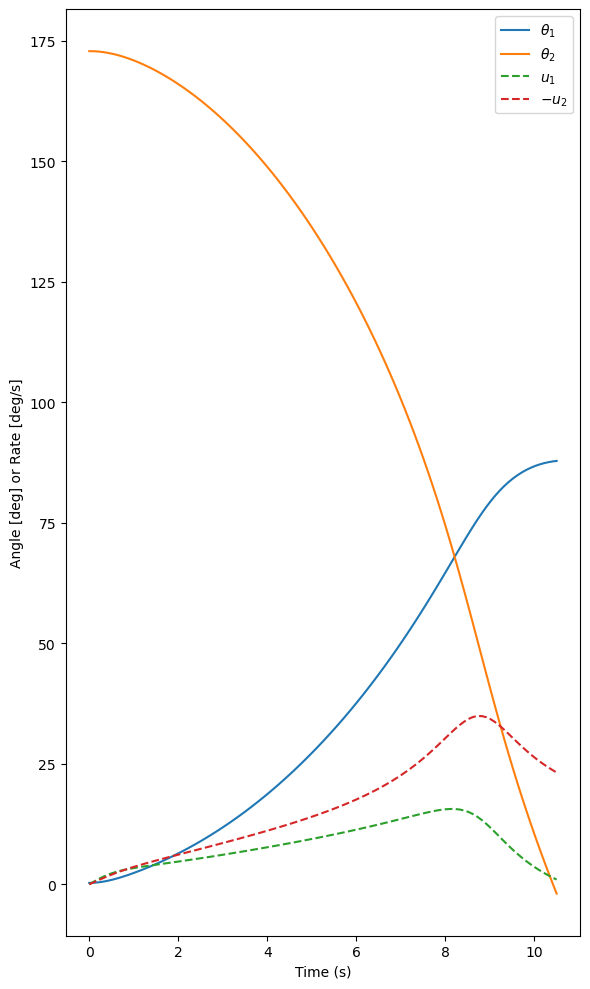

In [24]:
import matplotlib.pyplot as plt

u2_func = sm.lambdify((theta1, theta2, theta3, u1, parameters), ud_sol[0])

u2_vals = u2_func(ys[0,:], ys[1,:], ys[2,:], ys[3,:], p_vals)

fig, axes = plt.subplots(1,1, sharex=True)
fig.set_size_inches((6.0, 10.0))

axes.plot(ts, np.rad2deg(ys[0,:]))
axes.plot(ts, np.rad2deg(ys[1,:]))
axes.plot(ts, np.rad2deg(ys[3,:]), '--')
axes.plot(ts, np.rad2deg(-u2_vals), '--')
axes.legend([me.vlatex(qN[0], mode='inline'), me.vlatex(qN[1], mode='inline'), me.vlatex(uN[0], mode='inline'), me.vlatex(-uN[1], mode='inline')])
axes.set_xlabel('Time (s)')
axes.set_ylabel('Angle [deg] or Rate [deg/s]')

fig.tight_layout()
